## Análisis comparativo de estimaciones de LST en Bolonia

Comparación entre el modelo RF entrenado con datos de alta resolución (VANT)
y el modelo RF entrenado con datos globales abiertos.

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

In [2]:
# --- rutas de entrada ---
lst_observed          = '../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LST_clipped_celsius.tif'
lst_predicted_hr      = '../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/LST_predicted_RF.tif'
lst_predicted_global  = '../../datos-notebooks/2.global-data-bologna/LST-prediction/LST_predicted_RF.tif'

# --- rutas de salida ---
output_folder = '../../datos-notebooks/4.comparative-analysis/'
os.makedirs(output_folder, exist_ok=True)
out_diff      = os.path.join(output_folder, 'LST_difference_bologna.tif')
out_fig_maps  = os.path.join(output_folder, 'mapas_lst_comparacion.png')
out_fig_diff  = os.path.join(output_folder, 'diff_lst_hr_global.png')
out_fig_thr   = os.path.join(output_folder, 'umbral_lst.png')

In [3]:
def quantify(o, p, nodata=None):
    """Calcula métricas de error entre LST observada (o) y predicha (p)."""
    mask = np.isfinite(o) & np.isfinite(p)
    if nodata is not None:
        mask &= (o != nodata)
    o, p = o[mask], p[mask]
    print(f"  Bias  : {np.mean(p - o):.3f} °C")
    print(f"  MAE   : {np.mean(np.abs(p - o)):.3f} °C")
    print(f"  RMSE  : {np.sqrt(np.mean((p - o)**2)):.3f} °C")
    print(f"  r     : {np.corrcoef(o, p)[0, 1]:.3f}")

### 1. Métricas de error respecto a la LST observada

In [4]:
with rasterio.open(lst_observed) as s0:
    obs  = s0.read(1).astype('float32')
    nd   = s0.nodata

with rasterio.open(lst_predicted_hr) as s1:
    hr   = s1.read(1).astype('float32')

with rasterio.open(lst_predicted_global) as s2:
    glob = s2.read(1).astype('float32')

print('── Modelo HR (datos VANT) ──────────────────────────')
quantify(obs, hr, nd)

print('── Modelo global (datos abiertos) ──────────────────')
quantify(obs, glob, nd)

── Modelo HR (datos VANT) ──────────────────────────
  Bias  : 0.004 °C
  MAE   : 0.758 °C
  RMSE  : 1.049 °C
  r     : 0.945
── Modelo global (datos abiertos) ──────────────────
  Bias  : 0.002 °C
  MAE   : 0.700 °C
  RMSE  : 0.976 °C
  r     : 0.952


### 2. Mapas comparativos: LST observada, HR y global

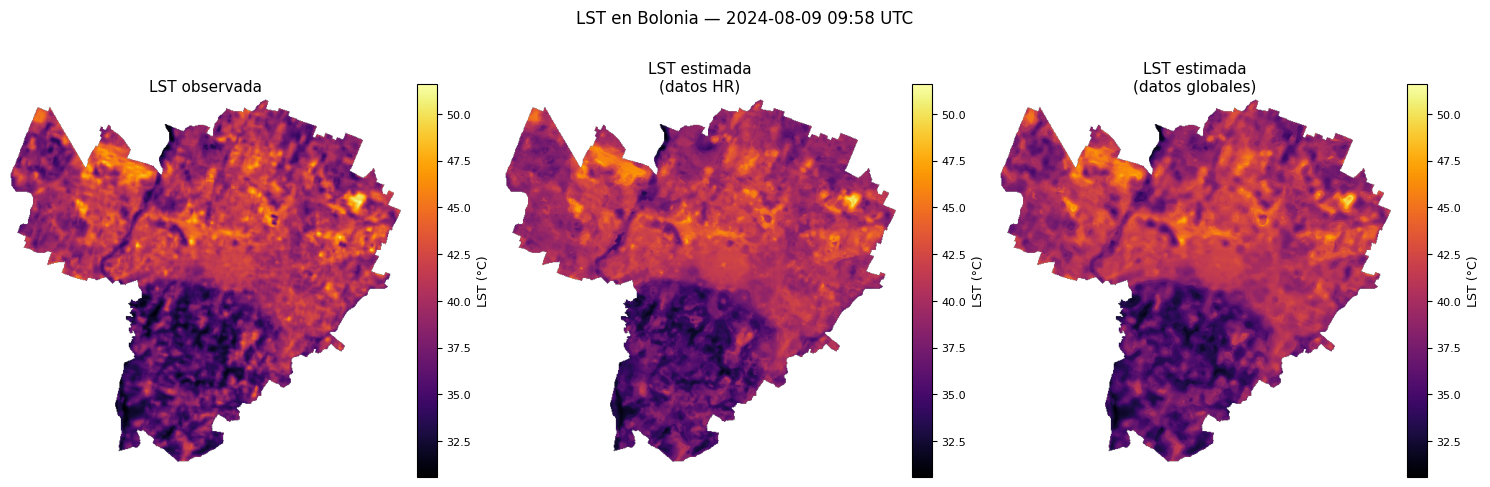

Guardado: ../../datos-notebooks/4.comparative-analysis/mapas_lst_comparacion.png


In [5]:
vmin = float(np.nanmin(obs))
vmax = float(np.nanmax(obs))

titles  = ['LST observada', 'LST estimada\n(datos HR)', 'LST estimada\n(datos globales)']
arrays  = [obs, hr, glob]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, arr, title in zip(axes, arrays, titles):
    im = ax.imshow(arr, cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('LST (°C)', fontsize=9)
    cb.ax.tick_params(labelsize=8)

plt.suptitle('LST en Bolonia — 2024-08-09 09:58 UTC', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(out_fig_maps, dpi=200, bbox_inches='tight')
plt.show()
print('Guardado:', out_fig_maps)

### 3. Diferencia espacial entre predicciones (HR − Global)

In [6]:
diff = hr - glob

# Guardar raster de diferencias
with rasterio.open(lst_predicted_hr) as src:
    profile = src.profile.copy()
profile.update(dtype='float32')
with rasterio.open(out_diff, 'w', **profile) as dst:
    dst.write(diff, 1)
print('Raster de diferencias guardado en:', out_diff)

Raster de diferencias guardado en: ../../datos-notebooks/4.comparative-analysis/LST_difference_bologna.tif


In [7]:
# Estadísticos de la diferencia
mask_d = np.isfinite(diff)
d = diff[mask_d]

print(f'Media      : {np.mean(d):.3f} °C')
print(f'Mediana    : {np.median(d):.3f} °C')
print(f'Desv. est. : {np.std(d):.3f} °C')
print(f'MAE        : {np.mean(np.abs(d)):.3f} °C')
print(f'RMSE       : {np.sqrt(np.mean(d**2)):.3f} °C')

Media      : 0.002 °C
Mediana    : -0.003 °C
Desv. est. : 0.855 °C
MAE        : 0.616 °C
RMSE       : 0.855 °C


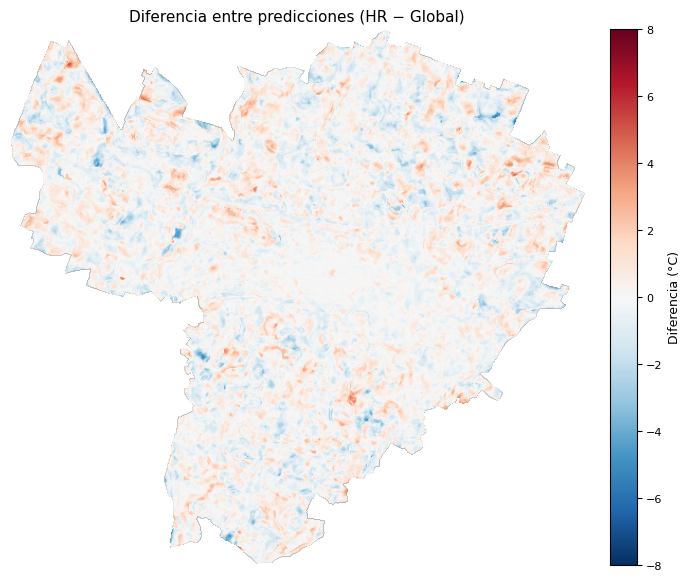

Guardado: ../../datos-notebooks/4.comparative-analysis/diff_lst_hr_global.png


In [8]:
# Mapa de diferencias
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(diff, cmap='RdBu_r', vmin=-8, vmax=8)
ax.axis('off')
ax.set_title('Diferencia entre predicciones (HR − Global)', fontsize=11)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
cb.set_label('Diferencia (°C)', fontsize=9)
cb.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(out_fig_diff, dpi=200, bbox_inches='tight')
plt.show()
print('Guardado:', out_fig_diff)

### 4. Porcentaje de píxeles por umbral de diferencia absoluta

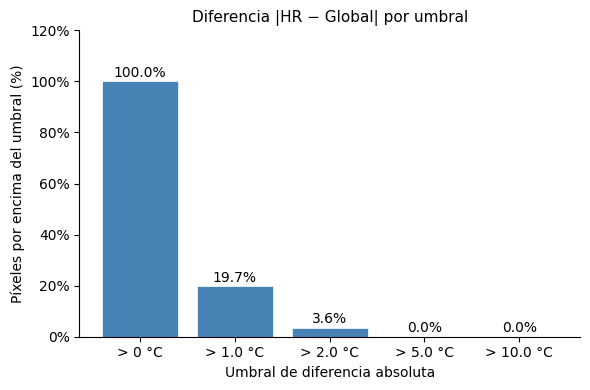

Guardado: ../../datos-notebooks/4.comparative-analysis/umbral_lst.png


In [10]:
thresholds = [0,1.0, 2.0, 5.0, 10.0]
fractions  = [float(np.mean(np.abs(d) > thr) * 100) for thr in thresholds]
labels     = [f'> {t} °C' for t in thresholds]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, fractions, color='steelblue', edgecolor='white', linewidth=0.5)

# Valores encima de cada barra
for bar, val in zip(bars, fractions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Umbral de diferencia absoluta', fontsize=10)
ax.set_ylabel('Píxeles por encima del umbral (%)', fontsize=10)
ax.set_title('Diferencia |HR − Global| por umbral', fontsize=11)
ax.set_ylim(0, max(fractions) * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(out_fig_thr, dpi=200, bbox_inches='tight')
plt.show()
print('Guardado:', out_fig_thr)